# Example Script: Attention map generation

This script will highlight all the steps that can be performed to investigate the attention of the DL model

In this example is the lung cancer patient cohort used to obtain the DL model with given weights

In [187]:
# Imports
%matplotlib inline
%load_ext autoreload
%autoreload 2

# import global libraries
import captum
from captum.attr._utils.input_layer_wrapper import ModelInputWrapper
from captum.attr import (
    IntegratedGradients,
    GuidedBackprop,
    GuidedGradCam,
    LayerGradCam,
    NoiseTunnel,
    GradientShap,)

import numpy as np
import torch
from torch.utils.data import DataLoader



# Local libraries enivironment loading
import os
import sys
from pathlib import Path
path_Project = Path(os.getcwd()).parent.parent
path_Git = path_Project.parent

def IncludeDirectory(path, index = 0, indexStop = -1):
    if(os.path.exists(path) and (index <= indexStop or indexStop == -1)):
        print(path)
        sys.path.append(path)
        children = os.listdir(path)
        for i in range(len(children)):
            pathChild = os.path.join(path,children[i])
            if(os.path.isdir(pathChild)):
                IncludeDirectory(pathChild, index + 1, indexStop)

# Activate the function
IncludeDirectory(path_Git,0,1)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\r.van.der.wal\Documents\GitHub
c:\Users\r.van.der.wal\Documents\GitHub\pred_RT


In [188]:
# Import local libraries
from src.constants import DEVICE
from src.utils.set_random_seed import set_random_seed
from src.models.tools.get_multi_model import get_classification_model
from src.config_presets.tools.get_config import get_config
from src.config_presets.tools.load_config import load_config
from src.dataset.load_dataset import load_dataset, load_dataset_total, load_dataset_single, Complete_SanityCheck
from src.training.train_multi import get_output_results, validate
from src.evaluation.get_total_evaluation import get_total_evaluation

### Loading the model and datasets

In [189]:
pathResultsChecked = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Trial_18\Kfold1" #r"C:\Users\r.van.der.wal\Documents\Detox_lung\Results\DETOX-Lung_Project_9\Trial_1\KFold0"
fileName_weights = r"DlModel_Weights.pth"

traindataset_path = os.path.join(pathResultsChecked,r"train_Dataset.csv") 
valdataset_path = os.path.join(pathResultsChecked,r"validation_Dataset.csv")
testdataset_path = os.path.join(pathResultsChecked,r"test_Dataset.csv")

# select if the config file is loaded with path or global
local_config = True
if(local_config):
    config = load_config(os.path.join(pathResultsChecked,"DlModel_Config.yaml")) #get_config('DETOXLung_config')
else:
    config = get_config('DETOXLung_config')

# Adjust the config from different environment to the current --> paths are different
config['paths']['csv'] = r"C:/Users/r.van.der.wal/Documents/Data/2024_09_04/ClinicalData/2024_11_01/"
config['paths']['images'] = r"C:/Users/r.van.der.wal/Documents/Data/2024_09_04/ImageData/"

# Disable randomness
set_random_seed(config['seed'])

# Set some variables to correct values
config['training']['batch_size'] = 1

pathModelWeigths = os.path.join(pathResultsChecked,fileName_weights)
datasets_col, metadata = load_dataset_total(config)
model = get_classification_model(config, metadata, False)
model.load_state_dict(torch.load(pathModelWeigths))
print("Succes loading model and datasets")

C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Trial_18\Kfold1\DlModel_Config.yaml
Removed ptns = 2
Class balance in training dataset is 0.5


c:\Users\r.van.der.wal\.conda\envs\test-env\Lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


succes


In [190]:
# Prerequisites to making the attention maps
config["data"]['augmentation']['isEnabled'] = False
dataloader = DataLoader(datasets_col[2][0], batch_size=config['training']['batch_size'], shuffle=False)  # a dataloader (can also just load one patient and put all the inputs into the correct tensor format)


## Wrapping the model in the Captum package's input wrapper

This allows the model to accept multiple inputs (i.e. the clinical features, and not just one array of image features)

In [191]:
DEVICE = torch.device('cuda:1')

In [192]:
# wrap the model with the ModelInputWrapper
model = ModelInputWrapper(model)

model.to(DEVICE)     # send the model to the GPU


ModelInputWrapper(
  (module): MultiTox_Classifier(
    (encoder): ResNet_LReLU(
      (conv1): Conv3d(3, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1)
      (maxpool): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (backbone): ModuleList(
        (0): Sequential(
          (0): BasicBlock(
            (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): LeakyReLU(negative_slope=0.1)
            (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (1): BasicBlock(
      

# Patient Selection

Get 2 patients that are interesting to check for the good prediction of a true positive and a true negative with large prediction value.

In [ ]:
# Get the AUC values for the test set
pathToStudy = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Trial_18"
pathToSaveResults = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Train" 
path_csv = r"C:/Users/r.van.der.wal/Documents/Data/2024_09_04/ClinicalData/2024_11_01/"
path_images = r"C:/Users/r.van.der.wal/Documents/Data/2024_09_04/ImageData/"
get_total_evaluation(pathToStudy,pathToSaveResults, path_csv, path_images, True, 0)

['Kfold0', 'Kfold1', 'Kfold2', 'Kfold3']
C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Trial_18\Kfold0\DlModel_Config.yaml
C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Trial_18\Kfold0\DlModel_Config.yaml


FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'C:\\Users\\r.van.der.wal\\Documents\\Detox_lung\\Validate_Models\\Trial_18_Check\\Train'

In [193]:
# Check for a given fold which patients are the best with RP = [True or False]
pathToSaveResults = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Trial_18_Check\Results" 

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

labels = list(pd.read_csv(os.path.join(pathToSaveResults,"labels.csv")).iloc[:,1])
predictions = list(pd.read_csv(os.path.join(pathToSaveResults,"predictions.csv")).iloc[:,1])
auc = roc_auc_score(labels, predictions)
print(auc)


0.7475615804265168


In [ ]:
def find_value_largest(numbers,value):
    return sorted(set(numbers))[value*-1]

minPred = np.min(predictions)
indexMin = predictions.index(minPred)
labelMin = labels[indexMin]

maxPred = find_value_largest(predictions,4)#np.max(predictions)
indexMax = predictions.index(maxPred)
labelMax = labels[indexMax]

print(f"Min prediction value {minPred} at index {indexMin} and label - {labelMin}")
print(f"Max prediction value {maxPred} at index {indexMax} and label - {labelMax}")

Min prediction value 0.0094630504364732 at index 340 and label - 0.0
Max prediction value 0.8469969591315103 at index 447 and label - 1.0


# Applying the attribution map method

You will have to chose a method with which to make the attention maps. Here, I show three of them, but more can be found on the website of the Captum package.
1. **Integrated Gradients**: returns an attention map that is the same size as the input. In other words, you get an attention map for each of the CT, dose, segmentations, and clinical features.
2. **GradientSHAP**: an approximation of the SHAP method, is fairly nice for assessing the importance of the clinical variables (but also works on the image data, I'm just not sure if you can really compare the attention on the clinical variables directly to the attention on the CT)
3. **GuidedGradCam**: this is similar to what Hung and Suzanne have used for the Xerostomia and Dysphagia models (same method, from a different library, as far as I'm aware. They used an adjusted version of the MedCam package). Unlike integrated gradients, this returns a 1 channel array, so you cannot tell the difference between the attentions on the CT or dose, as they are merged. You also have to pick a layer in the model to make attention maps on; thus this is not model agnostic, and means you might have to specifiy different layers if you are making attention maps for different models.


In [98]:
# import global libraries
import captum
import torch.nn.functional as F
from tqdm import tqdm
from captum.attr._utils.input_layer_wrapper import ModelInputWrapper
from captum.attr import (
    IntegratedGradients,
    GuidedBackprop,
    GuidedGradCam,
    LayerGradCam,
    NoiseTunnel,
    GradientShap,)

"""
1. Integrated Gradients
"""
#attr = IntegratedGradients(model)


"""
2. Gradient SHAP
"""
#attr = GradientShap(model)

"""
3. Gradient SHAP
"""
# features.denseblock_4.denselayer1.layers.conv1
attr = GuidedGradCam(model, model.module.encoder.backbone.block3[0]) # model.module.encoder.conv1)   # for a DenseNet model     


In [ ]:
# Get dataframe of patients with prediction and given label
def sigmoid(x):
    return 1/(1+np.exp(-x))

label = "RP_OneYear"
Sigmoid = np.vectorize(sigmoid)

df_prediction = pd.DataFrame()
index = 0

index_array = []
patientID_array = []
pred_array = []
label_array = []

model.eval()

for data in tqdm(dataloader):
    inputs, features, label_list = (
            data[0].to(DEVICE),
            data[1].to(DEVICE),
            data[2].to(DEVICE),
            )
    
    model_input = (torch.tensor(inputs), features)
    predFound = model(x=inputs, features= features)     
    pred = Sigmoid(predFound[label].cpu().detach().numpy())
    pred_array.append(pred)
    label_array.append(label_list[0])
    index_array.append(index)
    index = index + 1

df_prediction = pd.DataFrame({'pred':pred_array, 'label':label_array})


In [ ]:
# show dataframe and select on sorting an index of interest to get attention
df_prediction

In [239]:

%matplotlib inline
%load_ext autoreload
%autoreload 2

# put the model into evaluation mode ! this saves some GPU space
model.eval()

def sigmoid(x):
    return 1/(1+np.exp(-x))

label = "RP_OneYear"
Sigmoid = np.vectorize(sigmoid)
index = 0
indexTarget = 5
indexSkipped = []

for data in tqdm(dataloader):
    if(index == indexTarget or indexTarget == -1):
        # Load data, send it to the GPU
        inputs, features, label_list = (
            data[0].to(DEVICE),
            data[1].to(DEVICE),
            data[2].to(DEVICE),
            )

        if(index not in indexSkipped):
            # group the image inputs and the feature inputs into a tuple (this for the ModelInputWrapper)
            model_input = (torch.tensor(inputs), features) 

            # most methods require a baseline input. This is a fairly important choice, typically it is an array of zeros, but it can also be an array of pure noise or the mean of the dataset
            # these baselines are used to calculate the integral of the gradients, and they can have an effect on how the attention maps look (e.g. an all-zero baseline will lead to attention that highlights the white parts of the CT !)
            baseline_input = (torch.randn_like(torch.tensor(inputs)), torch.randn_like(features))  # random noise input
            #baseline_input = (torch.zeros_like(torch.tensor(inputs)), torch.zeros_like(features))  # all zeroes input
            

            # target index is the index of the class that we want to calculate the attention map for (i.e. the index of the value in the model's output tensor)
            # for single-toxicty models, I think it's just 0
            target_idx = 0
            # in Daniel's model code, this additional forward argument is used to make the model output in the shape of a tensor
            # normally the output is a dictionary {"Toxcity_A" : 1234, "Toxicity_B" : 5678, ...}, but for the attention maps, we need a tensor  [of shape (1, num_classes), I think]
            additional_forward_args = (1) 

            # the number of steps used by the approximation method (for integrated gradients, which uses 50 by default), it seems that more steps = more GPU useage
            n_steps = 1200
            batch_size = 16

            """
            For binary classification models:
            """
            # calculate the attention map: returns a tuple of two tensors, one tensor with the image attributions, and one with the clinical features attributions. They should have the same dimensions as the original input tensors.
            if(attr is IntegratedGradients):
                (image_attention, clinical_features_attention) = attr.attribute(model_input, baseline_input, additional_forward_args= additional_forward_args, n_steps=n_steps, internal_batch_size=batch_size)
            elif(attr is GuidedGradCam):
                (image_attention, clinical_features_attention) = attr.attribute(model_input, target=0, additional_forward_args= additional_forward_args, interpolate_mode="trilinear", attribute_to_layer_input=False)
            break

            # break after the first patient !!!!
            # (this is just so that it runs on one patient, for debugging. You can remove this when you want more patients)
    index +=1 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


 62%|██████▏   | 191/309 [00:36<00:22,  5.36it/s]C:\Users\r.van.der.wal\AppData\Local\Temp\2\ipykernel_10124\551052910.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_input = (torch.tensor(inputs), features)
C:\Users\r.van.der.wal\AppData\Local\Temp\2\ipykernel_10124\551052910.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  baseline_input = (torch.randn_like(torch.tensor(inputs)), torch.randn_like(features))  # random noise input
c:\Users\r.van.der.wal\.conda\envs\test-env\Lib\site-packages\captum\_utils\gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
c:\Users\r.van.der.wal\.conda\e

tensor([[1.]], device='cuda:1')
-10000000 inf


# Very basic plotting functions

In [240]:
# Get slice location where most attention is found
image_attention_np = image_attention.detach().cpu().numpy()
array = np.where(image_attention_np[0][1] == np.max(image_attention_np[0][1]))
print(array)

(array([129], dtype=int64), array([91], dtype=int64), array([127], dtype=int64))


-200
-200
0
-7.2507197e-07


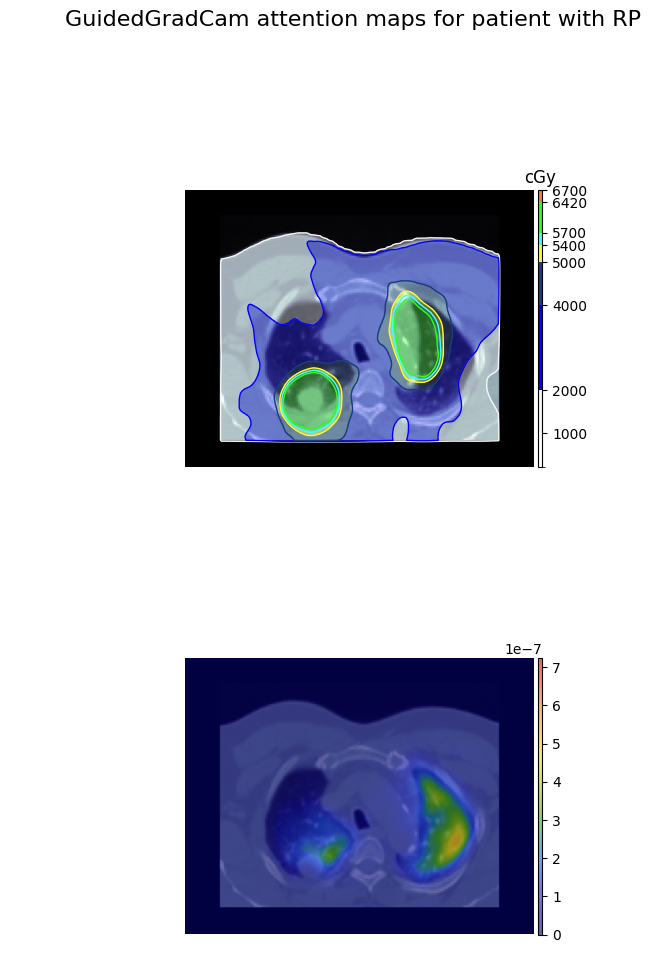

In [251]:
# Fast implementation for ESTRO Abstract deadline for DETOX-LUNG project

%matplotlib inline
from src.visualization.plot_slices import plot_slices
import matplotlib.pyplot as plt

inputs_np = inputs.detach().cpu().numpy()
image_attention_np = image_attention.detach().cpu().numpy()

CT = inputs_np[0][0]
RTDOSE = inputs_np[0][1]
RTSTRUCT = inputs_np[0][2]

from scipy.ndimage import gaussian_filter
kernel = np.array([0.25,0.5,1,0.5,0.25])

plotting_rows_dicts = [
            {
                "Label": "CT_RTDOSE",
                "CT": CT,
                "RTDOSE": RTDOSE,
            },
            {
                "Label": "CT_attention",
                "CT": CT,
                #"RTDOSE": RTDOSE,
                "Attention" : gaussian_filter(image_attention_np[0][1], sigma=2)
            }
        ]

slices = [120]

fig, axes = plot_slices(plotting_rows_dicts, slices, RTcmap="LUNG", title=f"GuidedGradCam attention maps for patient with RP")

for axes1 in axes:
    for axes2 in axes1:
        axes2.set_axis_off()

fig.savefig(r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Results\Attention_maps\RP_negative_max.png")


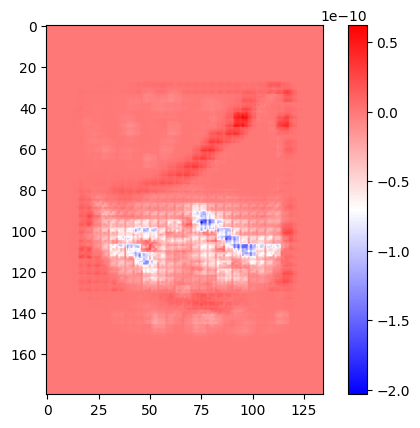

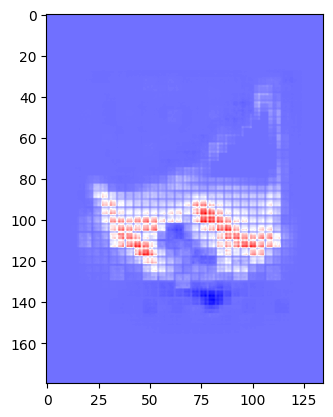

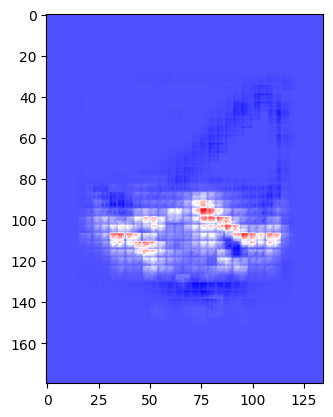

In [ ]:
# for the attention on the images

import matplotlib.pyplot as plt
import numpy as np


# plot slice #50 of the attention map
# the first "[0]" is to get the first patient from the batch size (even if the batch size is 1)
plt.imshow(image_attention[0][0,:,:,50].detach().cpu().numpy(), cmap='bwr')  #  0 = CT 
plt.colorbar()
plt.show()

plt.imshow(image_attention[0][1,:,:,50].detach().cpu().numpy(), cmap='bwr')  #  1 = dose
plt.show()

plt.imshow(image_attention[0][2,:,:,50].detach().cpu().numpy(), cmap='bwr')  #  2 = segmentation
plt.show()

TypeError: Invalid shape (0,) for image data

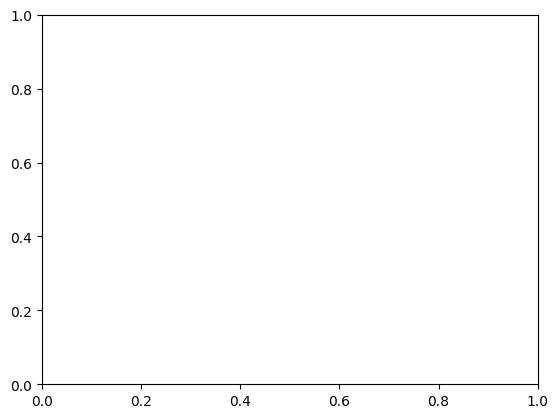

In [ ]:
# for the attention on the clinical features
import matplotlib.pyplot as plt
import numpy as np

features_dl = config['columns']['clinical_features']

fig, ax = plt.subplots()
 
im = ax.imshow(clinical_features_attention.cpu().numpy(), cmap='RdYlGn', alpha=1, aspect='auto')
#plt.set_yticks([])
ax.set_xticks(range(len(features_dl)), features_dl, rotation=90)
#ax.set_xticklabels(features[0].cpu().numpy(),rotation = 90, )
#ax.xticks(range(len(features_dl)), features_dl, rotation=90)
#ax.xlabel(features[0].cpu().numpy(),rotation = 90)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(range(len(features_dl)),features[0].cpu().numpy().astype(str),rotation = 90)

plt.colorbar(im)

#plt.colorbar()
plt.show()

You can also plot the attention map arrays using the same plot_slices functions as we used for the CT, dose and contours

In [ ]:
from src.visualization.plot_slices import plot_Attention

plot_Attention()

TypeError: plot_Attention() missing 5 required positional arguments: 'axs', 'Attention', 'slices', 'HNC_plotting_params', and 'global_att_max'

In [ ]:
X = np.linspace(0,CT.shape[1]-1,CT.shape[1])
Y = np.linspace(0,CT.shape[2]-1,CT.shape[2])
X,Y = np.meshgrid(X,Y)
X.shape, Y.shape

((170, 135), (170, 135))

In [ ]:
boundaries = np.arange(0.0,0.003,0.001)
boundaries

array([0.   , 0.001, 0.002])

In [ ]:
array1 = [[0,0,0,0]]*2
array1 = array1 + [[255,0,0,120],[255,0,0,200],[255,0,0,255]]
print(array1)
#rgbColors = np.array([[[0,0,0,0]]*2,[255,0,0,120],[255,0,0,200],[255,0,0,255]])/255.0


[[0, 0, 0, 0], [0, 0, 0, 0], [255, 0, 0, 120], [255, 0, 0, 200], [255, 0, 0, 255]]


In [ ]:
(np.array(RTDOSE[117])*60).max()

41.321583

0.0008334267613973049
[0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007]


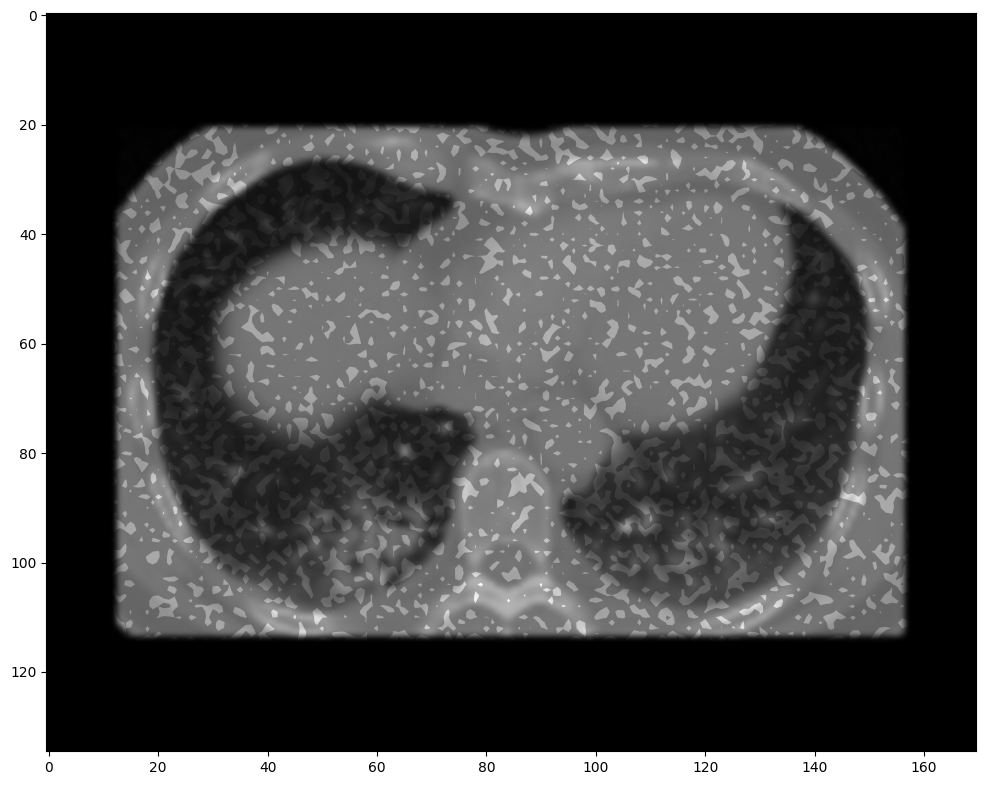

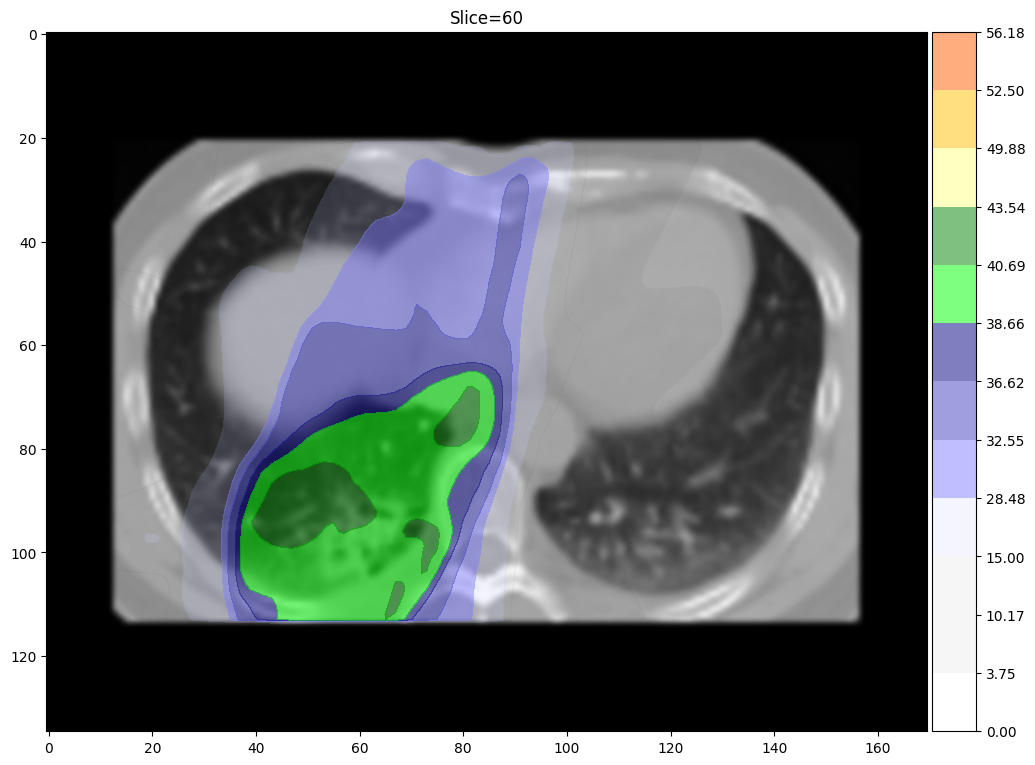

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def overlay_heatmap_on_ct(ctArray, heatmap, alpha = 0.4, sliceID = 120, setAttentionIndex = 3):
    fig = plt.figure(figsize=(12, 12))
    ax = plt.gca()

    X = np.linspace(0,CT.shape[2]-1,CT.shape[2])
    Y = np.linspace(0,CT.shape[1]-1,CT.shape[1])
    X,Y = np.meshgrid(X,Y)
    boundaries = np.arange(0.0,maxAttention-0.0001,0.0001)
    print(boundaries)
    array1 = [[0,0,0,0]]*setAttentionIndex
    array1 = array1 + [[255,0,0,200],[255,0,0,255]]
    rgbColors = np.array(array1)/255.0
    plt.rcParams["axes.grid"] = False
    ax.imshow(CT[sliceID], cmap='gray', interpolation='bicubic', alpha = 1.0)
    ax.contourf(X,Y,heatmap[sliceID],  colors = rgbColors, alpha = 0.3, levels = boundaries,  antialiased = True) # cmap = "coolwarm"
    fig.savefig(r"C:\Users\r.van.der.wal\Documents\Detox_lung\AttentionMaps\CT_Heatmap.png")

def overlay_dose_on_ct(ctArray, sliceDose, alpha = 0.4, sliceID = 120, setAttentionIndex = 3):
    boundaries = np.array([0, 5, 13.56, 20, 37.97, 43.40, 48.82, 51.54, 54.25, 58.05, 66.50, 70.00, 74.90])*3/4
    rgbColors = np.array(
        [[0, 0, 0, 0], [40, 40, 40, 10], [40, 40, 40, 10], [192, 192, 255, 40], [128, 128, 255, 128], [64, 64, 192, 128],
            [0, 0, 128, 128], [0, 255, 0, 128], [0, 128, 0, 128], [255, 255, 128, 128],
            [255, 192, 0, 128], [255, 90, 0, 128],[255, 0, 0, 128]]) / 255.0
    cmap = mcolors.ListedColormap(rgbColors)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N, clip=True)

    X = np.linspace(0, sliceDose.shape[2] - 1, sliceDose.shape[2])
    Y = np.linspace(0, sliceDose.shape[1] - 1, sliceDose.shape[1])
    X, Y = np.meshgrid(X, Y)

    f = plt.figure(figsize=(12, 12))
    plt.rcParams["axes.grid"] = False
    axarr = f.add_subplot(111)
    axarr.imshow(ctArray[sliceID], cmap='gray', interpolation='bicubic')
    realDose = np.array(sliceDose[sliceID])*60
    doseIm = axarr.contourf(X, Y, realDose, levels=boundaries, colors=rgbColors)

    axarr.set_title(f'Slice={sliceID}')
    
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(axarr)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    f.colorbar(doseIm, cax=cax, boundaries=boundaries, norm=norm, ticks=boundaries)
    f.savefig(r"C:\Users\r.van.der.wal\Documents\Detox_lung\AttentionMaps\CT_Dose.png")


sliceID = 60

inputs_np = inputs.cpu().numpy()
CT = inputs_np[0][0]
inputs_np = inputs.cpu().numpy()
heatmap = inputs_np[0][0]
image_attention_np = image_attention.cpu().numpy()
attentionSel = image_attention_np[0][0]
maxAttention = attentionSel.max()
print(maxAttention )
#boundaries = np.arange(-0.001,0.003,0.0005)
overlay_heatmap_on_ct(CT,image_attention_np[0][0], sliceID = sliceID, setAttentionIndex = 3)

# Also create image of the dose over the CT
RTDOSE = inputs_np[0][1]
overlay_dose_on_ct(CT,RTDOSE,sliceID = sliceID)




In [ ]:
image_attention.shape

torch.Size([1, 3, 180, 135, 170])

C:\Users\r.van.der.wal\AppData\Local\Temp\2\ipykernel_12760\2269063812.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


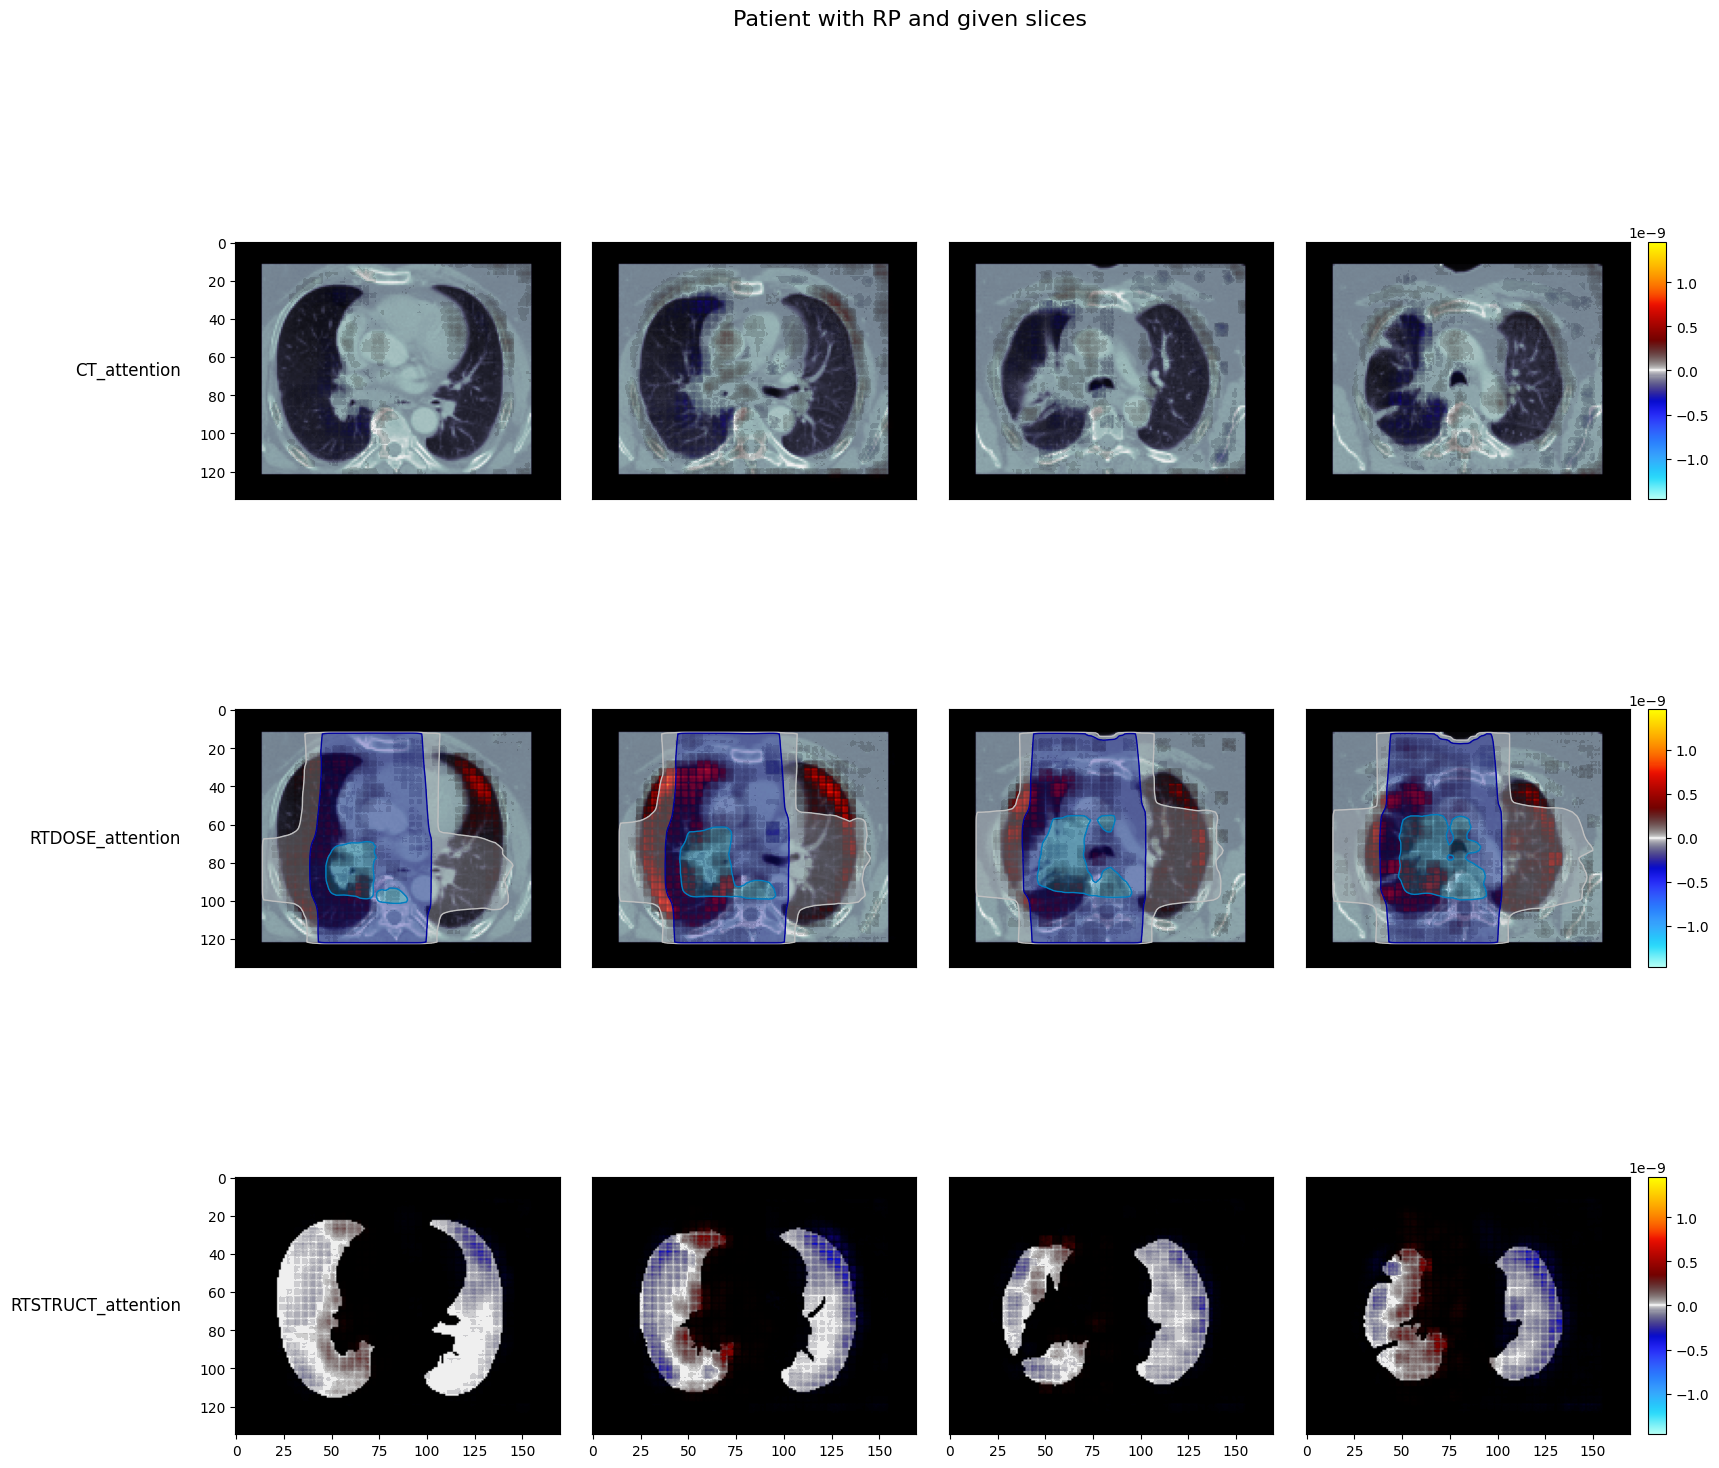

In [ ]:
%matplotlib inline
from src.visualization.plot_slices import plot_slices

inputs_np = inputs.detach().cpu().numpy()
image_attention_np = image_attention.detach().cpu().numpy()

CT = inputs_np[0][0]
RTDOSE = inputs_np[0][1]
RTSTRUCT = inputs_np[0][2]

plotting_rows_dicts = [
            {
                "Label": "CT_attention",
                "CT": CT,
                "Attention" : image_attention_np[0][0]
            },
            {
                "Label": "RTDOSE_attention",
                "CT": CT,
                "RTDOSE": RTDOSE,
                "Attention" : image_attention_np[0][1]
            },
            {
                "Label": "RTSTRUCT_attention",
                "RTSTRUCT": RTSTRUCT,
                "Attention" : image_attention_np[0][2]
            }
            #{
            #    "Label": "RTSTRUCT_attention",
            #    "RTSTRUCT": RTSTRUCT,
            #    "Attention" : image_attention[0][2].cpu().numpy()
            #}
        ]

slices = [90,100,110,115]

fig, axes = plot_slices(plotting_rows_dicts, slices , title=f"Patient with RP and given slices")
fig.savefig(r"C:\Users\r.van.der.wal\Documents\Detox_lung\Validate_Models\Results\Attention_maps\RP_negative_max.png")
fig.show()

# Check best Model on test dataset

In [ ]:
from src.Visualization.Confusion_matrix import *
from src.get_loss_function import get_loss_function 

#pathModelTestDataset = r"C:\Users\r.van.der.wal\Documents\Detox_lung\Results\DETOX-Lung_Project_9\Trial_0\\KFold0\test_Dataset.csv" 

rawTestLoader = load_dataset_single(valdataset_path,config)
datasetLoaderTest = DataLoader(rawTestLoader[0], batch_size=config['training']['batch_size'], shuffle=True) 
loss_function = get_loss_function(config)


In [ ]:
datasets = load_dataset_total(config)

Patient collection --> Train: 1236, Validation: 156
Patient collection --> Test: 156


In [ ]:
loss, auc = validate(loss_function, model, datasetLoaderTest, config)
print(f"Loss found = {loss}")
print(f"AUC found = {auc} ")

Loss found = 0.521340163644924
AUC found = {'RP_OneYear': 0.8877276490066225} 


In [ ]:
outputs,targets = get_output_results(loss_function, model, datasetLoaderTest, config)

In [ ]:
endpoints = list(outputs.keys())

endpointTargets = []
endpointPred = []

for i in range(len(endpoints)):
    endpointPred = outputs[endpoints[i]]
    endpointTargets = targets[endpoints[i]]
    #print(min(endpointPred))
    #print(max(endpointPred))
    for j in range(len(endpointPred)):
        print(f"target = {endpointTargets[j]}, pred = {endpointPred[j]}" )


target = 0.0, pred = 0.5726847648609351
target = 0.0, pred = 0.7354282799219172
target = 0.0, pred = 0.5547012347097915
target = 1.0, pred = 0.7281143874022595
target = 0.0, pred = 0.2797163760740568
target = 1.0, pred = 0.7585624884310493
target = 0.0, pred = 0.36881826918176736
target = 1.0, pred = 0.8537782989191898
target = 0.0, pred = 0.45686870452841766
target = 0.0, pred = 0.7133682773480854
target = 0.0, pred = 0.38843612799007265
target = 1.0, pred = 0.8966981848754432
target = 0.0, pred = 0.483239452559839
target = 0.0, pred = 0.3423344122299797
target = 1.0, pred = 0.7678730225390279
target = 0.0, pred = 0.22823632695686205
target = 0.0, pred = 0.7101810541032152
target = 0.0, pred = 0.16119586092183477
target = 0.0, pred = 0.4498615195877691
target = 1.0, pred = 0.8503557948078402
target = 1.0, pred = 0.8814474076410392
target = 0.0, pred = 0.5767408290346149
target = 0.0, pred = 0.754997157868072
target = 1.0, pred = 0.6287423061170633
target = 0.0, pred = 0.06961782285596

<Figure size 640x480 with 0 Axes>

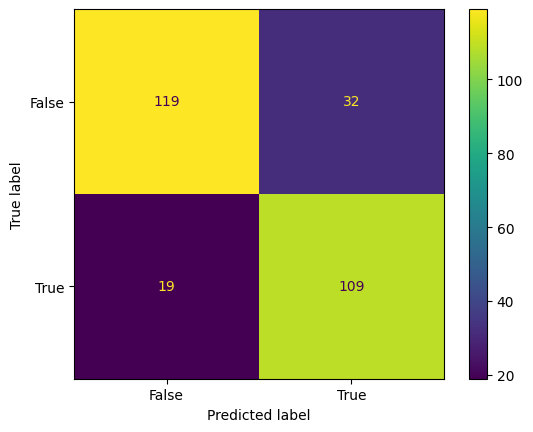

In [ ]:
confusion_matrix_bin(np.array(endpointTargets),np.array(endpointPred),config, True)

In [ ]:
# Help script
import pandas as pd
path = r"C:\Users\r.van.der.wal\Documents\Data\2024_09_04\ImageData"
listPatients = os.listdir(path)
dfLocal = pd.DataFrame(listPatients)
dfLocal[0].tolist()

pathSaved = r"C:\Users\r.van.der.wal\Documents\PtnsList.csv"
dfLocal.to_csv(pathSaved, sep = ";")